# cool_maps: Cartopy vs Basemap — Backend Parity Demo

cool_maps supports two mapping engines under the same API:

| Engine | Library | When to use |
|--------|---------|-------------|
| **cartopy** | `cartopy` | Default. Modern, actively maintained, lazy feature loading. |
| **basemap** | `mpl_toolkits.basemap` | Legacy environments, older HPC clusters. |

Every `cool_maps` function accepts an `engine=` keyword that overrides the active engine for that one call. You can also switch the global default with `cplt.set_engine()`. This notebook demonstrates that both backends produce **visually identical output** across the full set of `create()` options.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import cool_maps.plot as cplt

# Confirm which engines are available in this environment
available = cplt.available_engines()
print(f"Active engine : {cplt.get_engine()}")
print(f"Available     : {available}")

if "basemap" not in available:
    print("\nWarning: Basemap is not installed. Basemap cells will be skipped.")
    print("Install with: conda install -c conda-forge basemap basemap-data-hires")

Active engine : cartopy
Available     : ('cartopy', 'basemap')


In [2]:
# Gulf of Mexico — used as the reference domain throughout this notebook
EXTENT = [-99, -79, 18, 31]

ENGINES = [e for e in ("cartopy", "basemap") if e in cplt.available_engines()]


def compare(extent, title, **create_kwargs):
    """
    Call cplt.create() once per available engine and display the results
    side-by-side (or one after the other if only one engine is available).

    All keyword arguments are forwarded to cplt.create() for both engines.
    Use cartopy_kwargs / basemap_kwargs dicts to pass engine-specific overrides.
    """
    cartopy_extra = create_kwargs.pop("cartopy_kwargs", {})
    basemap_extra = create_kwargs.pop("basemap_kwargs", {})

    for engine in ENGINES:
        extra = cartopy_extra if engine == "cartopy" else basemap_extra
        fig, ax = cplt.create(extent, engine=engine, **create_kwargs, **extra)
        ax.set_title(f"{engine.title()}  |  {title}", fontsize=13, fontweight="bold", pad=8)
        plt.tight_layout()
        plt.show()
        plt.close(fig)


print("Helper function defined. Ready to go!")

Helper function defined. Ready to go!


---
## 1. Basic Map

The simplest call: `cplt.create(extent)`. Both engines should render tan land, a blue ocean, full-resolution GSHHS coastlines, state/country borders, rivers, and DMS-formatted tick labels.

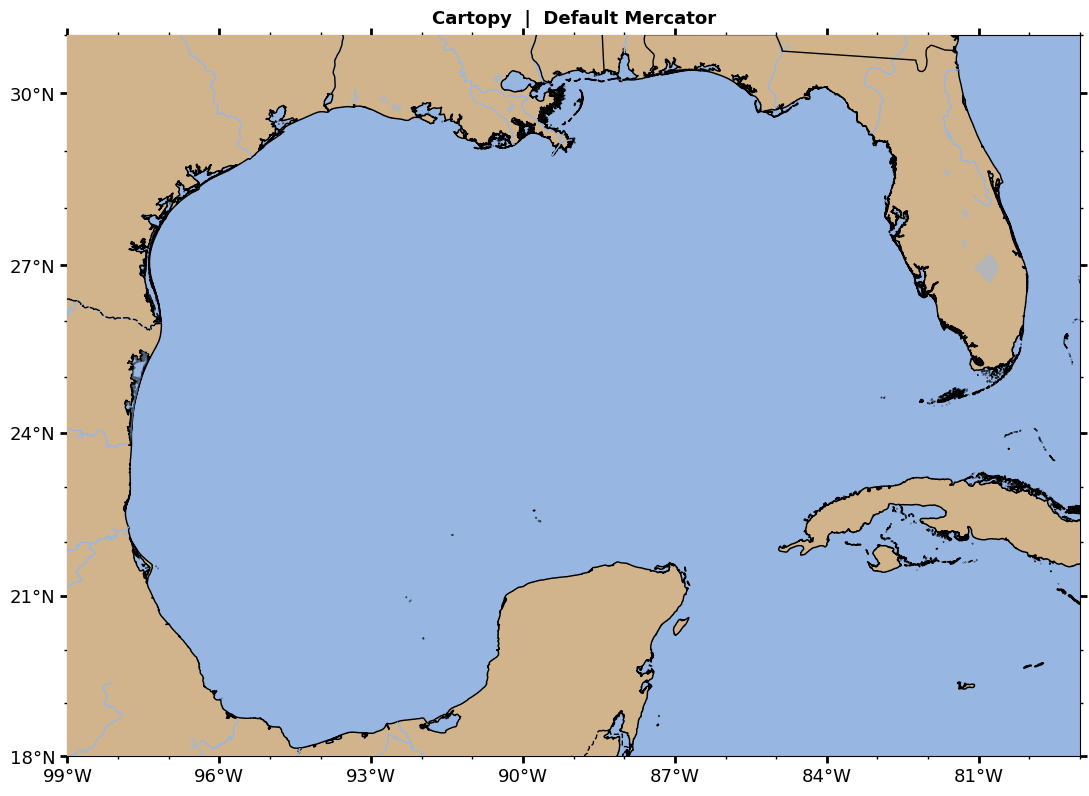

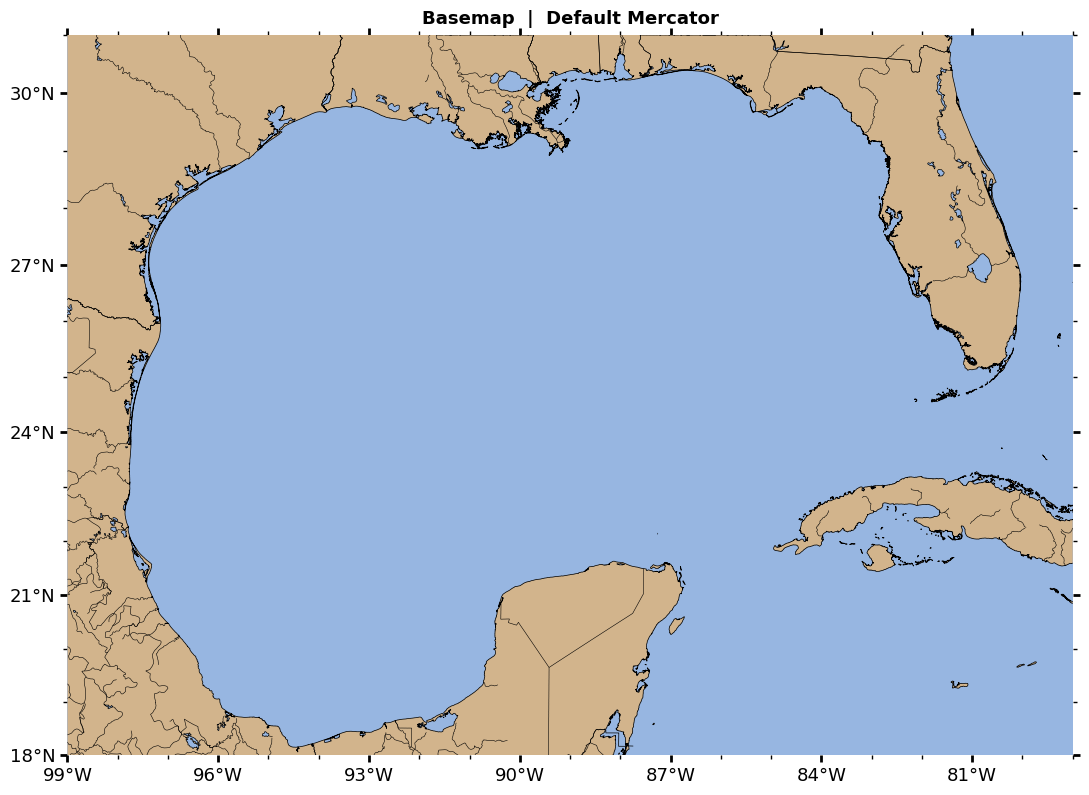

In [3]:
compare(EXTENT, "Default Mercator")

---
## 2. Projection Support

Both engines accept the **same projection strings**. cool_maps translates the string to the correct backend-specific object internally.

Supported strings: `"mercator"`, `"platecarree"`, `"lambertcylindrical"`, `"mill"`, `"orthographic"`, `"lambertconformal"`, `"stereographic"`, `"azimuthequidistant"`

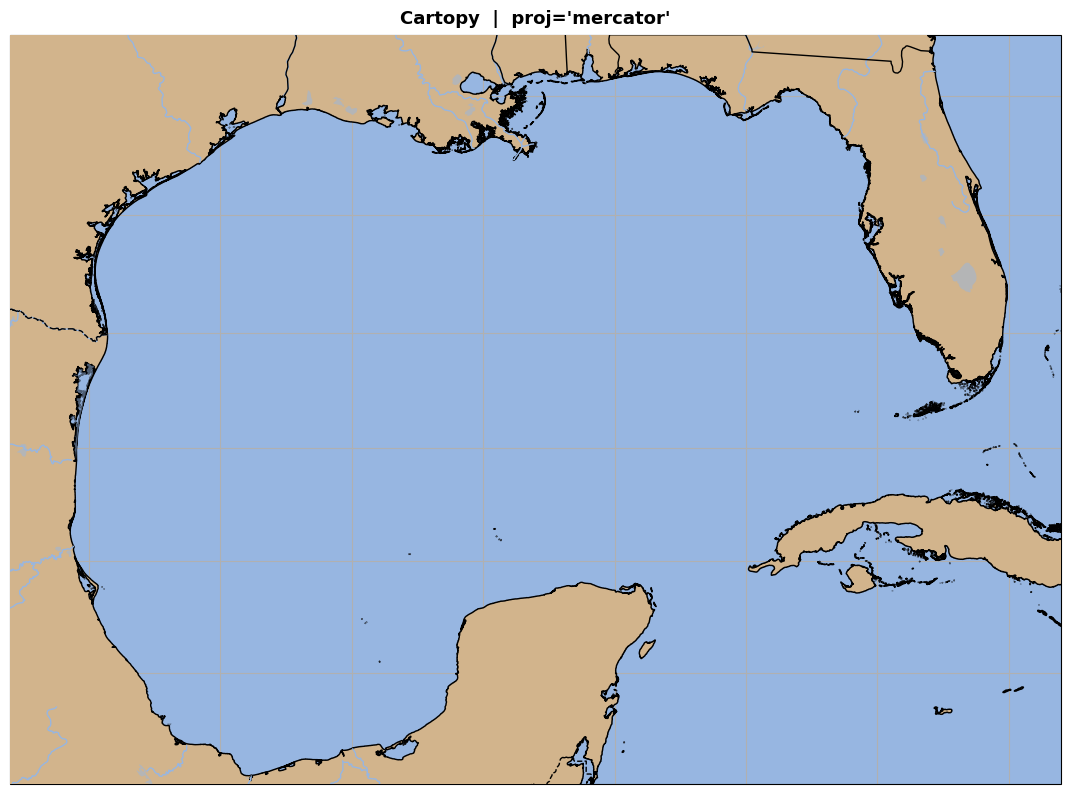

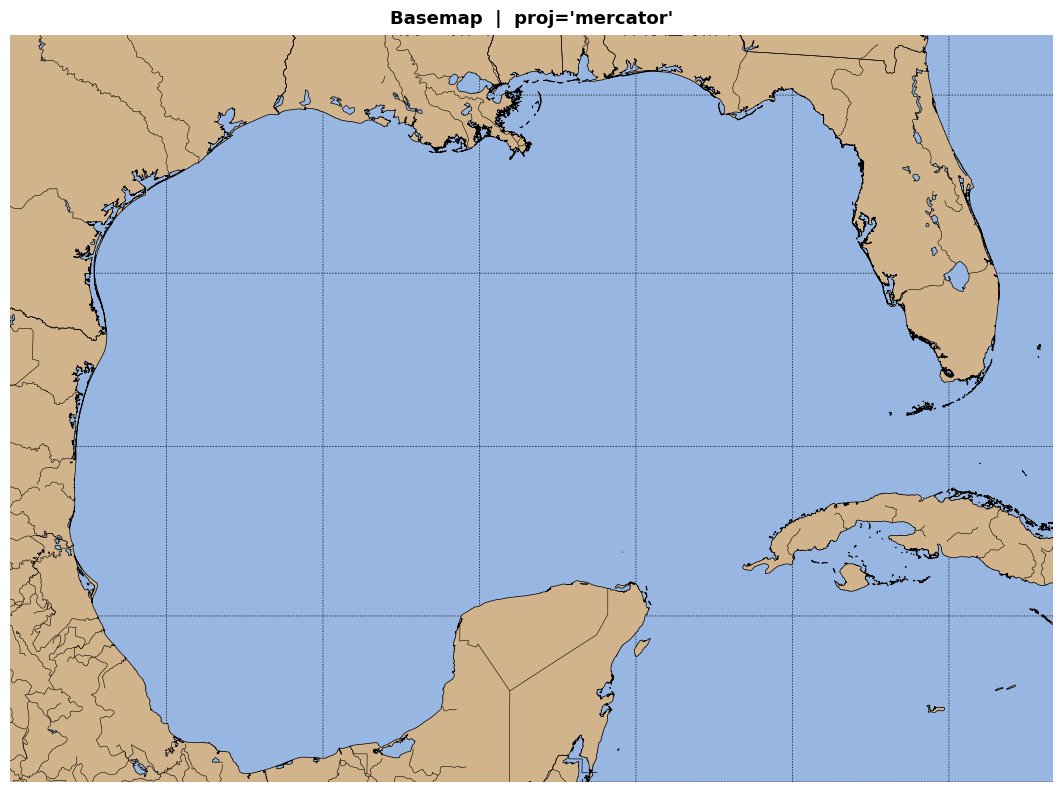

In [4]:
# Mercator (the default — shown explicitly here)
compare(EXTENT, "proj='mercator'", proj="mercator", ticks=False, gridlines=True)

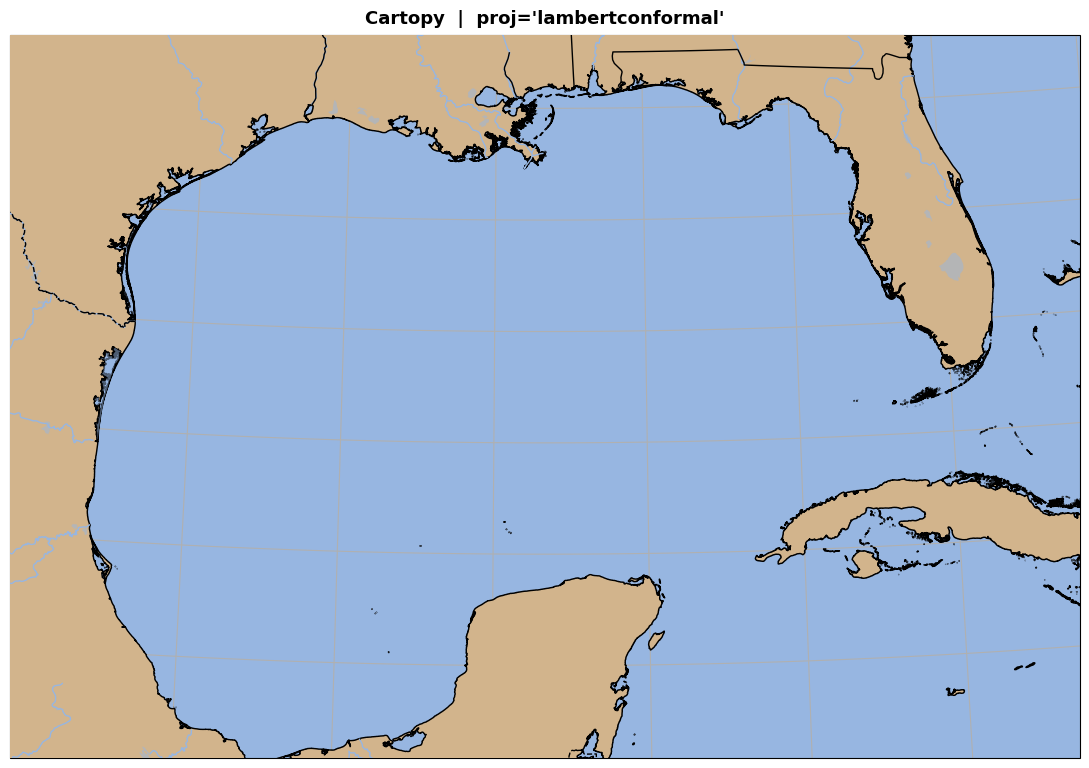

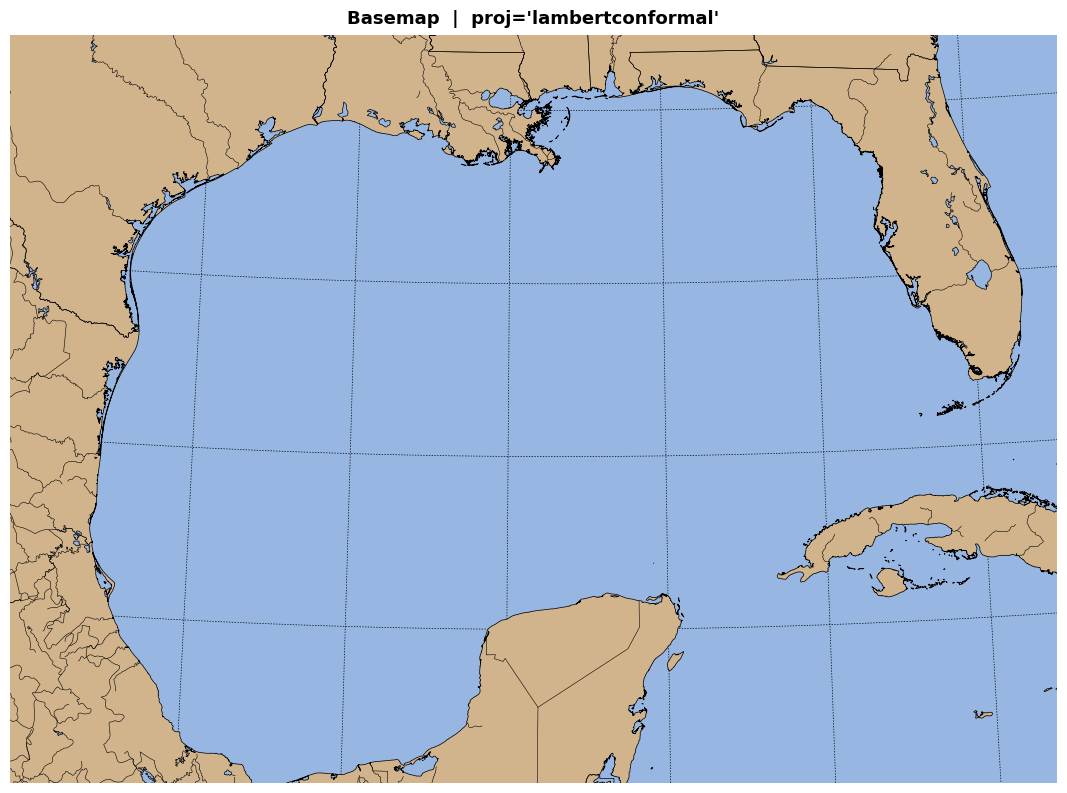

In [5]:
# Lambert Conformal — standard projection for mid-latitude meteorology
# Standard parallels and central longitude are derived automatically from the extent
compare(EXTENT, "proj='lambertconformal'", proj="lambertconformal", ticks=False, gridlines=True)

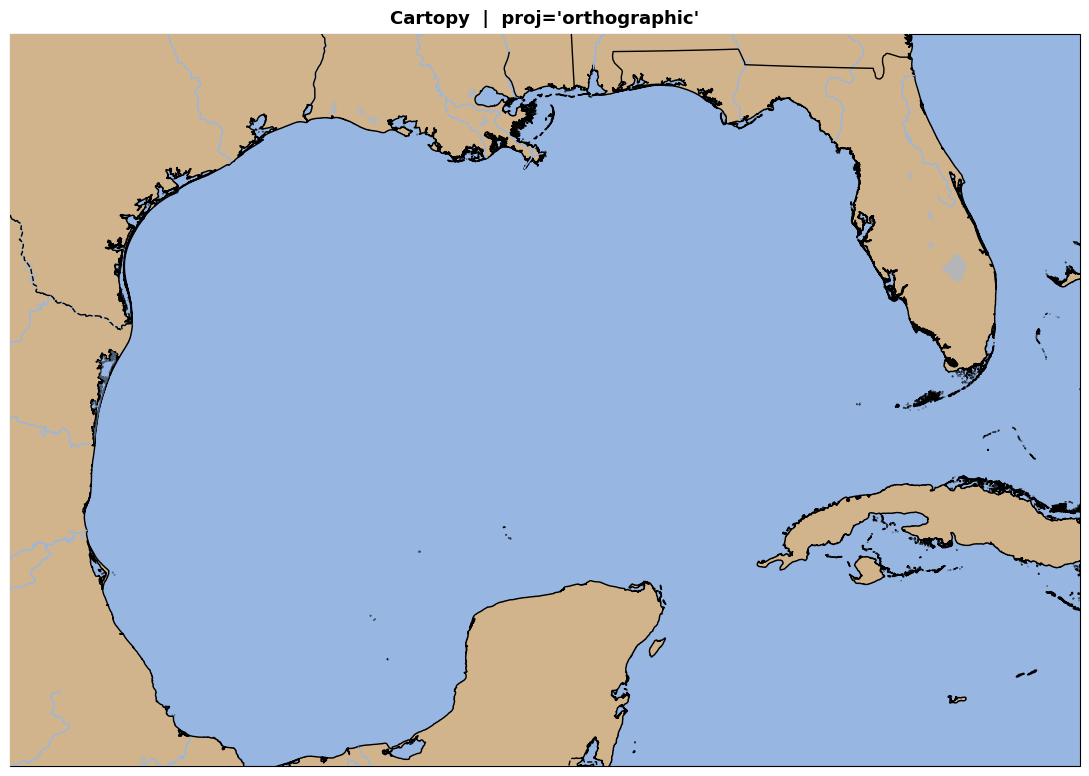

AttributeError: 'Basemap' object has no attribute '_height'

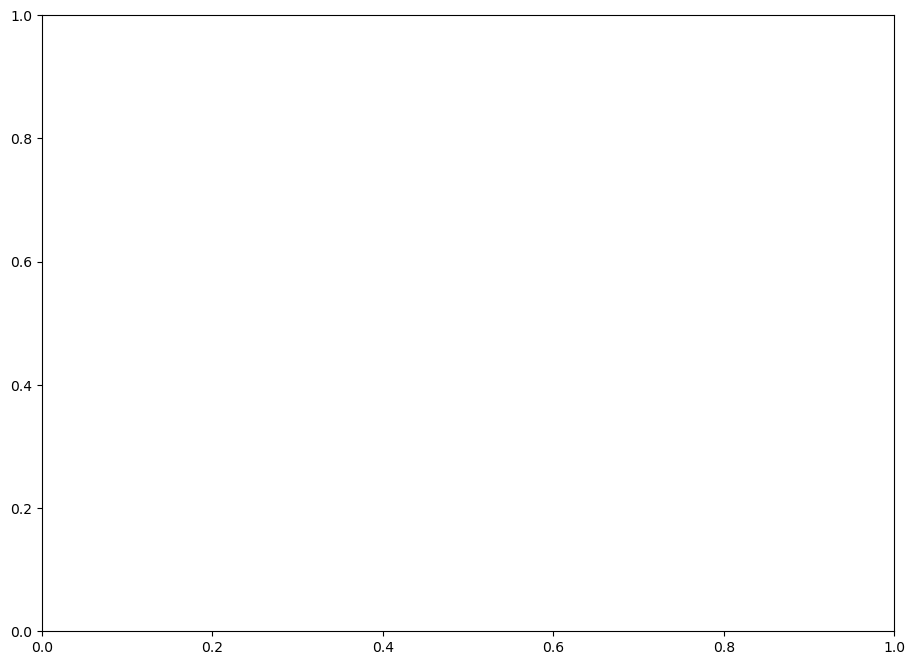

In [6]:
# Orthographic — globe view centred on the extent
compare(EXTENT, "proj='orthographic'", proj="orthographic", ticks=False, gridlines=False)

In [ ]:
# Stereographic — used for polar and high-latitude oceanography
compare(EXTENT, "proj='stereographic'", proj="stereographic", ticks=False, gridlines=True)

---
## 3. Coastline Resolution

The `coast=` parameter controls the level of detail for the coastline polygon. For Cartopy, this selects the GSHHS or NaturalEarth dataset; for Basemap, it sets the `resolution=` kwarg at initialisation.

| `coast=` | Cartopy source | Basemap code |
|----------|---------------|-------------|
| `"full"` | GSHHS full | `"f"` |
| `"high"` | NaturalEarth 10m | `"h"` |
| `"mid"` | NaturalEarth 50m | `"i"` |
| `"low"` | NaturalEarth 110m | `"l"` |
| `"crude"` | NaturalEarth 110m | `"c"` |

> **Performance note**: Basemap loads the entire coastline dataset into RAM at initialisation. At `coast="full"` this can take several seconds and consume significant memory. Cartopy lazy-loads and clips to the map extent, so it scales better for repeated calls.

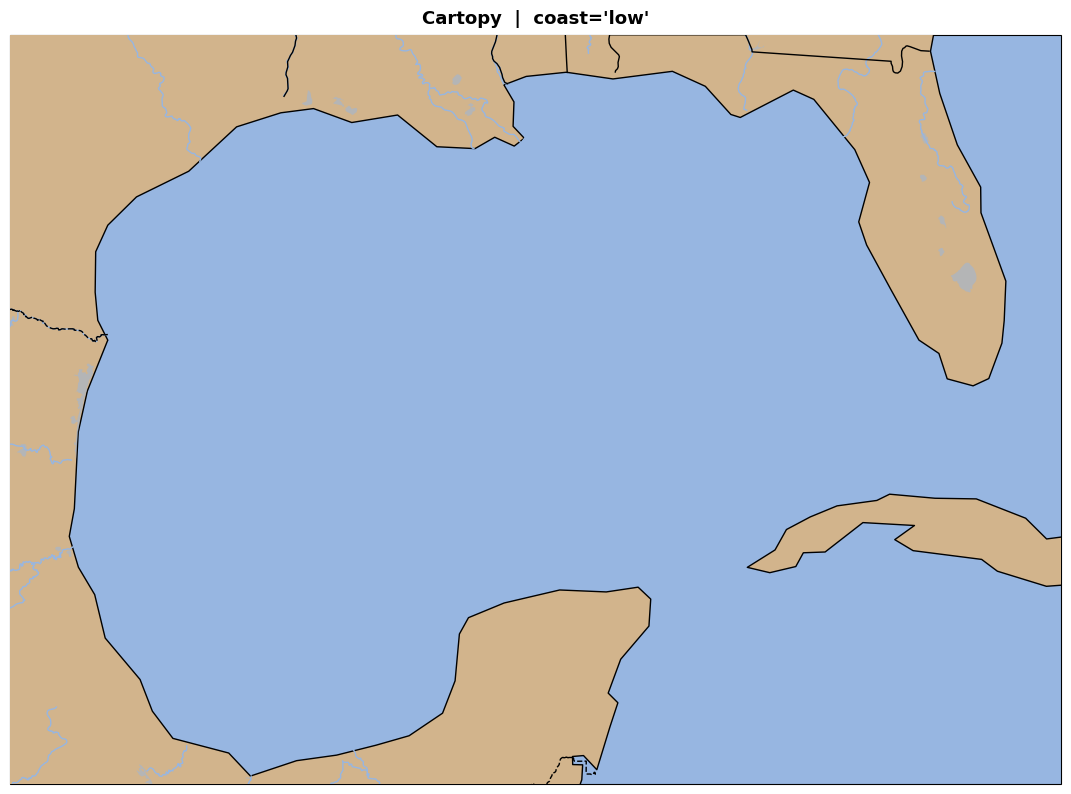

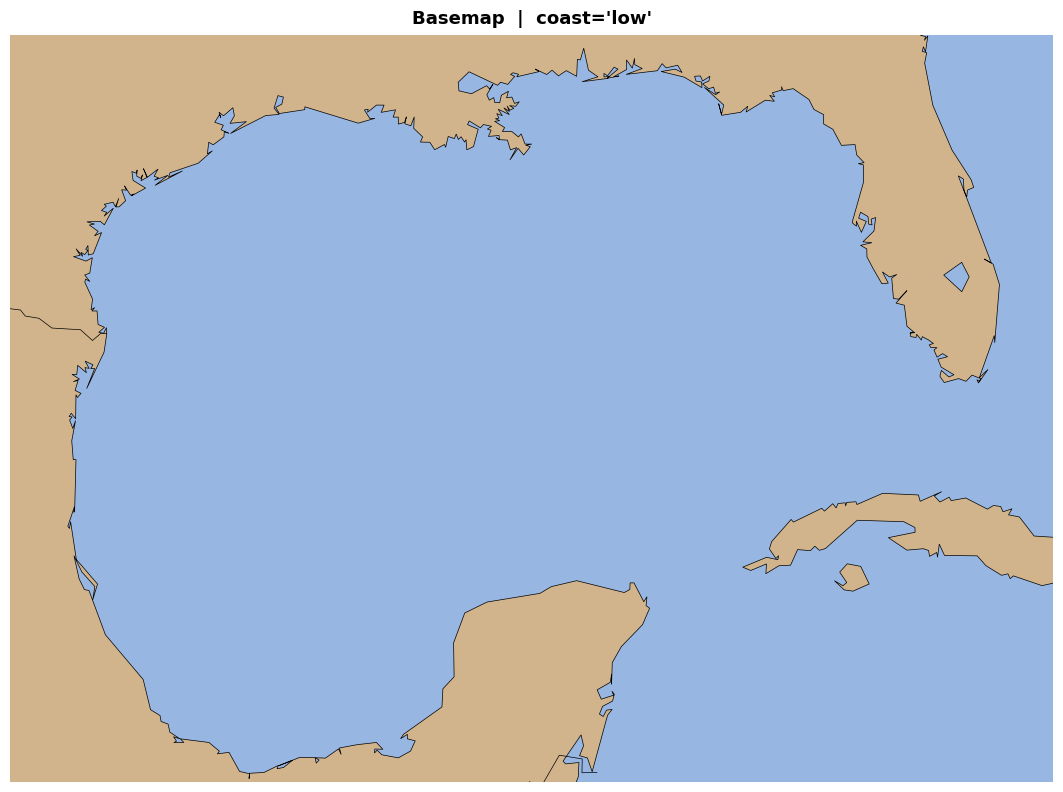

In [7]:
# Low resolution — fast, suitable for global/basin-scale maps
compare(EXTENT, "coast='low'", coast="low", ticks=False)

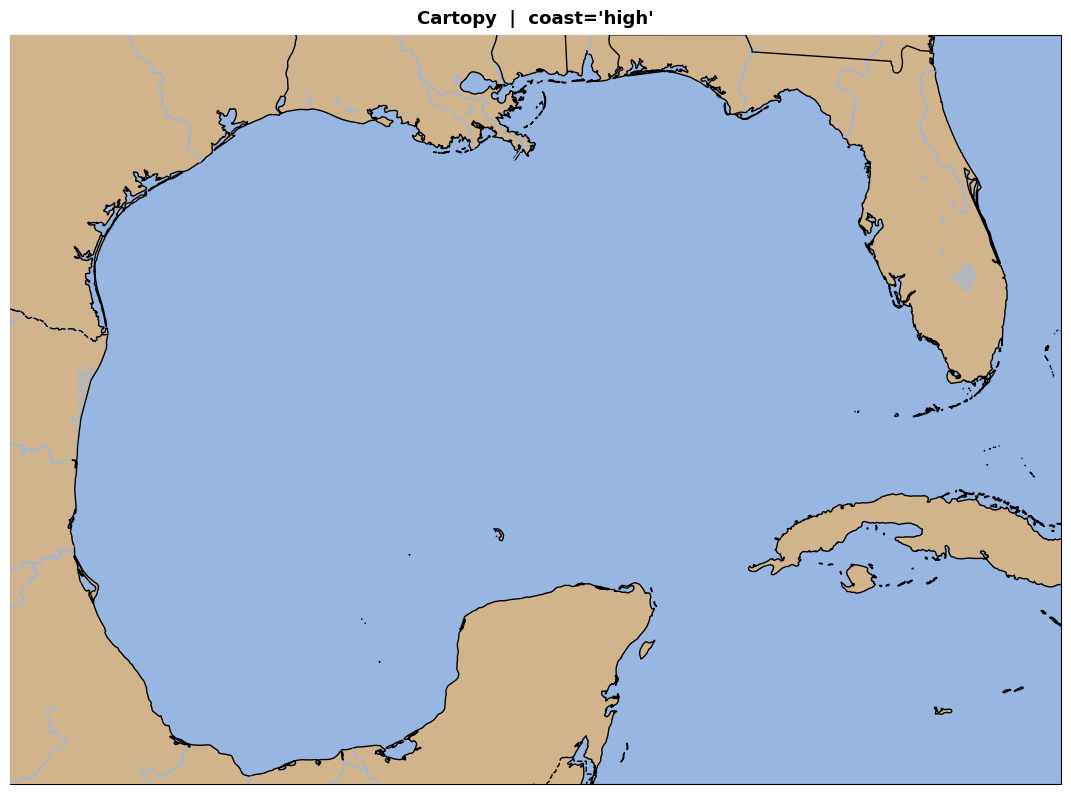

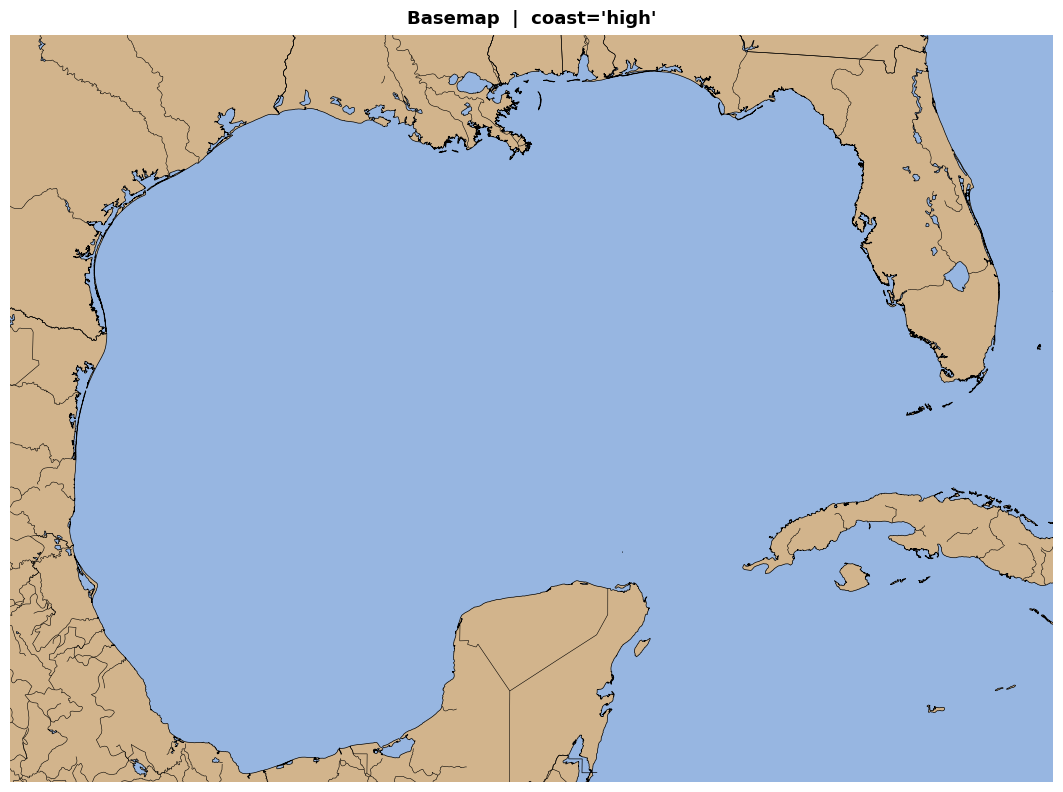

In [8]:
# High resolution — detailed, best for regional/coastal maps
# Note: slower to render than 'low' or 'mid'
compare(EXTENT, "coast='high'", coast="high", ticks=False)

---
## 4. Color Customisation

`create()` exposes three color knobs that work identically on both engines:

- `landcolor` — fill color for land polygons (default `"tan"`)
- `oceancolor` — background/water color (default: Cartopy's standard water blue)
- `edgecolor` — border/coastline color (default `"black"`)

In [ ]:
# Default palette for reference
compare(EXTENT, "Default colors", coast="low", ticks=False)

In [ ]:
# Publication-style greyscale
compare(
    EXTENT,
    "Greyscale palette",
    coast="low",
    ticks=False,
    landcolor="#d0d0d0",
    oceancolor="#f0f4f8",
    edgecolor="#555555",
)

In [ ]:
# Dark theme — useful for overlaying satellite-derived SST or chlorophyll
compare(
    EXTENT,
    "Dark theme",
    coast="low",
    ticks=False,
    landcolor="#2b2b2b",
    oceancolor="#0d1b2a",
    edgecolor="#888888",
)

---
## 5. Ticks and Gridlines

- `ticks=True` (default) — smart tick spacing computed from the extent; supports DMS labels
- `decimal_degrees=True` — switch tick labels to decimal degrees instead of DMS
- `gridlines=True` — overlay a dashed grid at the minor tick positions
- `tick_label_left/right/bottom/top` — control which sides carry labels

The tick positions are calculated once by `cool_maps.calc.calculate_ticks()` and then applied to whichever backend is active, so spacing is guaranteed to be identical.

In [ ]:
# Default DMS tick labels
compare(EXTENT, "DMS ticks (default)", coast="low")

In [ ]:
# Decimal degree tick labels
compare(EXTENT, "Decimal degree ticks", coast="low", decimal_degrees=True)

In [ ]:
# Ticks + gridlines
compare(EXTENT, "Ticks + gridlines", coast="low", gridlines=True)

In [ ]:
# Labels on all four sides — useful for multi-panel figures
compare(
    EXTENT,
    "Labels on all four sides",
    coast="low",
    tick_label_left=True,
    tick_label_right=True,
    tick_label_bottom=True,
    tick_label_top=True,
)

---
## 6. Bathymetry

`bathymetry=True` downloads GEBCO 2023 data from the Rutgers THREDDS server and overlays it.

The `bathymetry_method=` parameter selects the rendering style:

| Method | Description |
|--------|-------------|
| `"contour"` | Black isobath lines at `isobaths` depths (default) |
| `"shadedcontour"` | Greyscale isobaths that darken with depth |
| `"blues"` | `pcolormesh` using Blues colormap; land masked |
| `"blues_log"` | Same with log-transformed depth |
| `"topo"` | `pcolormesh` using cmocean `topo`; land masked |
| `"topofull"` | `pcolormesh` using cmocean `topo`; land included |

> Coordinate transformation is handled differently under the hood — Cartopy uses the `transform=` keyword, Basemap uses `latlon=True` — but `cool_maps` applies the same `_preprocess_elevation()` function to the data before branching, so numerical results are identical.

Under the hood, `get_bathymetry()` automatically splits large extents into 10-degree tiles before
requesting them from the THREDDS server (which rejects single OpenDAP requests that are too large),
then stitches the tiles back together. This is transparent when going through `bathymetry=True`; call
`get_bathymetry()` directly and pass `chunk_size=` to change the tile size, or `chunk_size=None` to
disable it.

In [ ]:
# Default contour isobaths at -1000 m and -100 m
compare(EXTENT, "bathymetry_method='contour'", bathymetry=True, coast="low")

In [ ]:
# Shaded contours — more isobaths, greyscale gradient
compare(
    EXTENT,
    "bathymetry_method='shadedcontour'",
    bathymetry=True,
    bathymetry_method="shadedcontour",
    isobaths=(-3000, -2000, -1000, -500, -200, -100),
    coast="low",
)

In [ ]:
# Blues pcolormesh — continuous depth shading, land masked
compare(
    EXTENT,
    "bathymetry_method='blues'",
    bathymetry=True,
    bathymetry_method="blues",
    coast="low",
    ticks=False,
)

In [ ]:
# Topo colormap — diverging palette for land + ocean elevation
compare(
    EXTENT,
    "bathymetry_method='topofull'",
    bathymetry=True,
    bathymetry_method="topofull",
    coast="low",
    ticks=False,
    landcolor="none",  # let the topo colormap show land too
)

---
## 7. Overlaying Oceanographic Data

After `create()` returns, you have a matplotlib `ax` instrumented by cool_maps: `ax.scatter`, `ax.plot`, `ax.contour`, `ax.contourf`, `ax.pcolormesh`, `ax.quiver`, and `ax.fill` all accept plain lon/lat data directly under either engine. cool_maps injects the right `transform=` (Cartopy) or `latlon=True` (Basemap) for you automatically -- you can still pass your own to override it.

Below we generate synthetic SST anomaly data and scatter it onto the map, with the exact same code for both engines.

In [ ]:
rng = np.random.default_rng(42)

# Fake glider track across the Gulf of Mexico
n = 120
lons = np.linspace(-95, -82, n) + rng.normal(0, 0.3, n)
lats = np.linspace(25, 28, n) + rng.normal(0, 0.15, n)
sst_anom = np.sin(np.linspace(0, 3 * np.pi, n)) * 2.5 + rng.normal(0, 0.3, n)

# The exact same plotting code works under either engine -- no transform=/latlon=
# needed, no reaching into `ax._cool_maps_basemap` to project coordinates by hand.
for engine in ENGINES:
    fig, ax = cplt.create(EXTENT, engine=engine, coast="low")
    sc = ax.scatter(
        lons, lats,
        c=sst_anom,
        cmap="RdBu_r",
        vmin=-3, vmax=3,
        s=20,
        zorder=200,
    )
    plt.colorbar(sc, ax=ax, label="SST anomaly (°C)", shrink=0.7)
    ax.set_title(f"{engine.title()}  |  Glider SST anomaly", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

---
## 8. Switching Engines Per Call

You can mix engines within the same notebook session using the `engine=` parameter on any `cool_maps` function. The global engine set by `set_engine()` is used as the fallback when `engine=` is omitted.

In [ ]:
print("Global engine before:", cplt.get_engine())

# Cartopy map without changing the global default
fig, ax = cplt.create(EXTENT, engine="cartopy", coast="low", ticks=False)
ax.set_title("engine='cartopy' (per call)", fontsize=13, fontweight="bold")
plt.show()
plt.close(fig)

print("Global engine after: ", cplt.get_engine(), "  ← unchanged")

In [ ]:
if "basemap" in ENGINES:
    # Switch the global default, then use the module without specifying engine=
    cplt.set_engine("basemap")
    print("Global engine:", cplt.get_engine())

    fig, ax = cplt.create(EXTENT, coast="low", ticks=False)
    ax.set_title("Global engine = 'basemap'", fontsize=13, fontweight="bold")
    plt.show()
    plt.close(fig)

    # Always restore to cartopy when done
    cplt.set_engine("cartopy")
    print("Restored to:", cplt.get_engine())

---
## 9. Known Differences Between Backends

While `cool_maps` aims for visual parity, a few genuine differences exist due to the underlying libraries:

| Feature | Cartopy | Basemap |
|---------|---------|--------|
| **Coastline loading** | Lazy -- clips to extent | Eager -- full dataset at init |
| **Rivers/states at `coast="crude"`** | Omitted (110m NE) | Omitted (no data at resolution `"c"`) |
| **`coast="full"` speed** | Fast (extent-clipped GSHHS) | Slow (global GSHHS in RAM) |
| **`transform=`/`latlon=` for user data** | Injected automatically by cool_maps' axes; pass your own to override | Injected automatically by cool_maps' axes; pass your own to override |
| **Orthographic globe clipping** | Clean circular boundary | Square boundary visible outside the globe |

For oceanographic data visualisation (always in lon/lat coordinates), these differences are cosmetic and do not affect the spatial accuracy of plotted features.

---
## Summary

```python
import cool_maps.plot as cplt

# Check what's installed
cplt.available_engines()        # ('cartopy', 'basemap')

# Use a specific engine for one call
fig, ax = cplt.create(extent, engine="basemap")

# Switch globally for a whole session
cplt.set_engine("basemap")
fig, ax = cplt.create(extent)   # uses basemap
cplt.set_engine("cartopy")      # restore

# Projection strings work for both backends
fig, ax = cplt.create(extent, proj="lambertconformal", engine="basemap")
fig, ax = cplt.create(extent, proj="lambertconformal", engine="cartopy")

# The axes returned by create() remembers which engine built it, so engine=
# is optional on every downstream call -- only pass it to override:
cplt.add_features(ax)
cplt.add_bathymetry(ax, lon, lat, elevation)

# Plain lon/lat data works directly on the returned axes, regardless of engine:
ax.scatter(lon, lat, c=values)
ax.pcolormesh(lons, lats, field)
```

The `engine=` parameter is supported by all public `cool_maps` functions:
`create()`, `add_bathymetry()`, `add_features()`, `add_ticks()`, `add_currents()`.

---
## 10. Performance Benchmark

The two backends have different initialisation strategies:

- **Cartopy** lazy-loads coastline data and clips it to the map extent. Subsequent calls at the same resolution are faster because the data is cached in memory.
- **Basemap** loads the *entire* coastline dataset into RAM at `Basemap()` construction time, regardless of extent. Every `create()` call pays this cost in full.

The cell below times `cplt.create()` across three coastline resolutions and visualises the results. `coast="full"` is excluded for Basemap because it can take 30+ seconds per call and would dominate the chart.

Benchmarking 3 reps per configuration ...

Engine     coast      mean (s)    std (s)
------------------------------------------
cartopy    crude         0.019      0.020
cartopy    low           0.004      0.000
cartopy    mid           0.004      0.000
cartopy    high          0.004      0.000
basemap    crude         0.019      0.001
basemap    low           0.070      0.001
basemap    mid           0.389      0.007
basemap    high          1.592      0.015



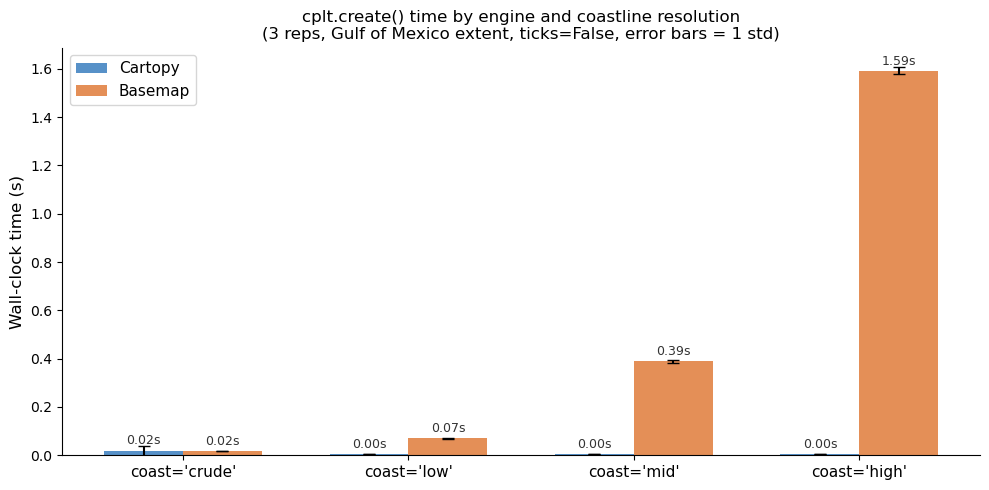

Basemap / Cartopy mean time ratio:
  coast='crude': 1.0× faster
  coast='high': 413.8× slower
  coast='low': 17.3× slower
  coast='mid': 103.2× slower


In [5]:
import time

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

N_REPS = 3  # repetitions per configuration

# coast levels to benchmark; skip 'full' for basemap (extremely slow)
COAST_LEVELS = ["crude", "low", "mid", "high"]
BASEMAP_SKIP = {"full"}  # resolutions to skip for basemap


def time_create(engine, coast, n=N_REPS):
    """Return mean and std of wall-clock time for cplt.create() over n repetitions."""
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        fig, ax = cplt.create(
            EXTENT,
            engine=engine,
            coast=coast,
            ticks=False,
            features=True,
            bathymetry=False,
        )
        plt.close(fig)
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.std(times))


# --- Run the benchmark ---
results = {engine: {} for engine in ENGINES}

print(f"Benchmarking {N_REPS} reps per configuration ...\n")
print(f"{'Engine':<10} {'coast':<8} {'mean (s)':>10} {'std (s)':>10}")
print("-" * 42)

for engine in ENGINES:
    for coast in COAST_LEVELS:
        if engine == "basemap" and coast in BASEMAP_SKIP:
            print(f"{engine:<10} {coast:<8} {'(skipped — too slow)':>21}")
            continue
        mean, std = time_create(engine, coast)
        results[engine][coast] = (mean, std)
        print(f"{engine:<10} {coast:<8} {mean:>10.3f} {std:>10.3f}")

print()

# --- Plot ---
engine_colors = {"cartopy": "#3a7ebf", "basemap": "#e07b39"}

fig, ax = plt.subplots(figsize=(10, 5))

n_levels = len(COAST_LEVELS)
n_engines = len(ENGINES)
bar_w = 0.35
x = np.arange(n_levels)

for i, engine in enumerate(ENGINES):
    means, stds, labels = [], [], []
    for coast in COAST_LEVELS:
        if coast in results[engine]:
            m, s = results[engine][coast]
            means.append(m)
            stds.append(s)
        else:
            means.append(0)
            stds.append(0)

    offset = (i - (n_engines - 1) / 2) * bar_w
    bars = ax.bar(
        x + offset,
        means,
        bar_w,
        yerr=stds,
        capsize=4,
        color=engine_colors.get(engine, "grey"),
        alpha=0.85,
        label=engine.title(),
        error_kw={"elinewidth": 1.5},
    )

    # Label each bar with the mean time
    for bar, mean in zip(bars, means):
        if mean > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(stds) * 0.15 + 0.01,
                f"{mean:.2f}s",
                ha="center", va="bottom",
                fontsize=9, color="#333333",
            )

ax.set_xticks(x)
ax.set_xticklabels([f"coast='{c}'" for c in COAST_LEVELS], fontsize=11)
ax.set_ylabel("Wall-clock time (s)", fontsize=12)
ax.set_title(
    f"cplt.create() time by engine and coastline resolution\n"
    f"({N_REPS} reps, Gulf of Mexico extent, ticks=False, error bars = 1 std)",
    fontsize=12,
)
ax.legend(fontsize=11)
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)

# Annotate basemap skipped bars
for coast in BASEMAP_SKIP:
    if "basemap" in ENGINES and coast in COAST_LEVELS:
        idx = COAST_LEVELS.index(coast)
        i = ENGINES.index("basemap")
        offset = (i - (n_engines - 1) / 2) * bar_w
        ax.text(
            idx + offset, 0.02,
            "skipped",
            ha="center", va="bottom",
            fontsize=8, color="grey", rotation=90,
        )

plt.tight_layout()
plt.show()
plt.close(fig)

# --- Summary interpretation ---
if "cartopy" in results and "basemap" in results:
    shared = set(results["cartopy"]) & set(results["basemap"])
    if shared:
        ratios = {
            c: results["basemap"][c][0] / results["cartopy"][c][0]
            for c in shared
        }
        print("Basemap / Cartopy mean time ratio:")
        for coast, ratio in sorted(ratios.items()):
            slower = "slower" if ratio > 1 else "faster"
            print(f"  coast='{coast}': {ratio:.1f}× {slower}")

---
## 11. Multi-Dataset Overlay: Where Cartopy's Transform Cost Accumulates

The engine initialisation benchmark above favours Cartopy because Basemap pays a large up-front coastline-loading cost. Once the map *exists*, the picture reverses.

Every Cartopy plot call with `transform=` runs the full PROJ coordinate pipeline on that call's array — it is not cached between calls. With 6 datasets overlaid, that is 6 independent reprojection passes. Basemap's `bm(lons, lats)` is plain NumPy; you pay it once per dataset and then plot in already-projected pixel coordinates.

The cell below:
1. Creates the base map once (outside the timed region) to isolate data-plotting cost.
2. Generates 6 independent synthetic datasets of configurable grid size.
3. Times plotting all 6 datasets on the pre-existing axes using each backend's idiom.
4. Repeats for three grid sizes to show how the gap scales with array size.

Method                                 grid   mean (s)      std
---------------------------------------------------------------
Cartopy  transform=                   50×40      0.008    0.001
Basemap  pre-project                  50×40      0.007    0.000
Basemap  latlon=True                  50×40      0.007    0.000

Cartopy  transform=                 200×150      0.061    0.014
Basemap  pre-project                200×150      0.022    0.001
Basemap  latlon=True                200×150      0.025    0.004

Cartopy  transform=                 500×400      0.334    0.037
Basemap  pre-project                500×400      0.109    0.001
Basemap  latlon=True                500×400      0.118    0.007



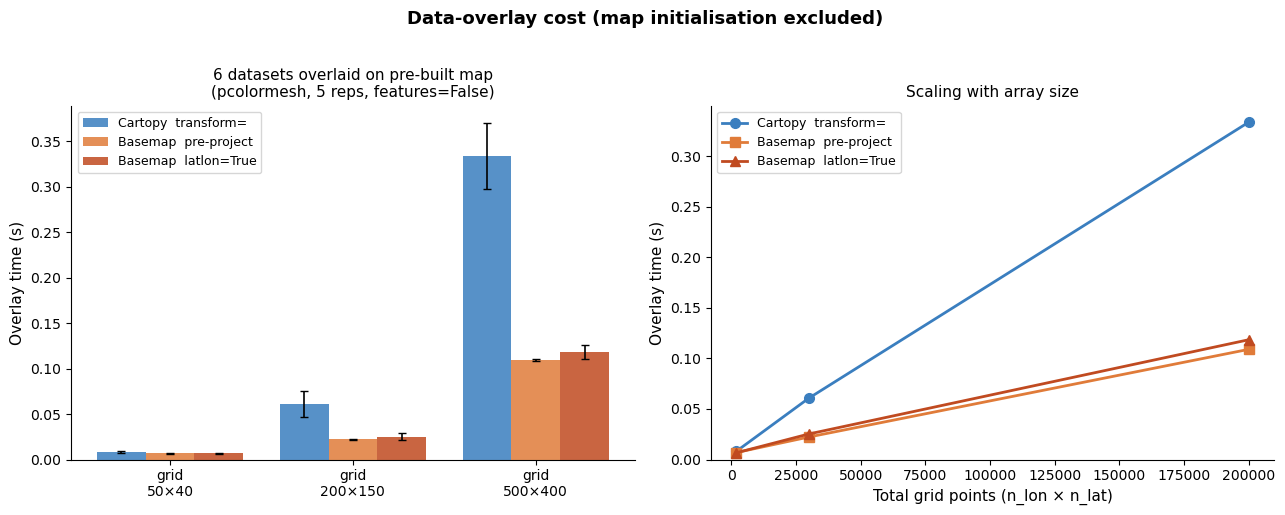

Cartopy transform= vs Basemap pre-project ratio (overlay only):
  grid    50×40:  Cartopy 0.008s  /  Basemap 0.007s  → 1.2× (Basemap faster)
  grid  200×150:  Cartopy 0.061s  /  Basemap 0.022s  → 2.7× (Basemap faster)
  grid  500×400:  Cartopy 0.334s  /  Basemap 0.109s  → 3.1× (Basemap faster)


In [6]:
import time
import matplotlib.pyplot as plt
import numpy as np

N_DATASETS = 6
N_REPS = 5
# Grid sizes to test: (n_lon, n_lat)
GRID_SIZES = [(50, 40), (200, 150), (500, 400)]

rng = np.random.default_rng(0)


def make_datasets(n_lon, n_lat):
    """Return N_DATASETS synthetic (lon, lat, value) grids covering EXTENT."""
    lon = np.linspace(EXTENT[0], EXTENT[1], n_lon)
    lat = np.linspace(EXTENT[2], EXTENT[3], n_lat)
    lons, lats = np.meshgrid(lon, lat)
    datasets = []
    for _ in range(N_DATASETS):
        values = rng.standard_normal((n_lat, n_lon))
        datasets.append((lon, lat, lons, lats, values))
    return datasets


def time_cartopy_overlay(datasets, n=N_REPS):
    """
    Time the cost of plotting N_DATASETS pcolormesh layers on a pre-built
    Cartopy GeoAxes using transform=ccrs.PlateCarree() on every call.
    """
    import cartopy.crs as ccrs

    times = []
    for _ in range(n):
        # Build the base map outside the timed region
        fig, ax = cplt.create(EXTENT, engine="cartopy", coast="low",
                               ticks=False, features=False)
        t0 = time.perf_counter()
        for lon, lat, lons, lats, values in datasets:
            # transform= is re-evaluated on every call
            ax.pcolormesh(
                lons, lats, values,
                transform=ccrs.PlateCarree(),
                shading="auto",
                alpha=0.4,
            )
        times.append(time.perf_counter() - t0)
        plt.close(fig)
    return float(np.mean(times)), float(np.std(times))


def time_basemap_overlay(datasets, n=N_REPS):
    """
    Time the cost of plotting N_DATASETS pcolormesh layers on a pre-built
    Basemap axes.

    Strategy A — pre-project once per dataset with bm(lons, lats), then
    use plain matplotlib pcolormesh (no per-call transform overhead).
    """
    times = []
    for _ in range(n):
        fig, ax = cplt.create(EXTENT, engine="basemap", coast="low",
                               ticks=False, features=False)
        bm = getattr(ax, "_cool_maps_basemap")

        t0 = time.perf_counter()
        for lon, lat, lons, lats, values in datasets:
            # Project once, then hand off to plain matplotlib
            x, y = bm(lons, lats)
            ax.pcolormesh(x, y, values, shading="auto", alpha=0.4)
        times.append(time.perf_counter() - t0)
        plt.close(fig)
    return float(np.mean(times)), float(np.std(times))


def time_basemap_latlon(datasets, n=N_REPS):
    """
    Strategy B — use Basemap's own pcolormesh with latlon=True.
    Basemap projects internally, but only once per call (not through
    Cartopy's multi-step pipeline).
    """
    times = []
    for _ in range(n):
        fig, ax = cplt.create(EXTENT, engine="basemap", coast="low",
                               ticks=False, features=False)
        bm = getattr(ax, "_cool_maps_basemap")

        t0 = time.perf_counter()
        for lon, lat, lons, lats, values in datasets:
            bm.pcolormesh(lons, lats, values,
                          latlon=True, shading="auto", alpha=0.4)
        times.append(time.perf_counter() - t0)
        plt.close(fig)
    return float(np.mean(times)), float(np.std(times))


# ── Run benchmark ──────────────────────────────────────────────────────────
results = []  # (label, grid_size_str, mean, std)

header = f"{'Method':<30} {'grid':>12} {'mean (s)':>10} {'std':>8}"
print(header)
print("-" * len(header))

for n_lon, n_lat in GRID_SIZES:
    grid_label = f"{n_lon}×{n_lat}"
    datasets = make_datasets(n_lon, n_lat)

    if "cartopy" in ENGINES:
        m, s = time_cartopy_overlay(datasets)
        results.append(("Cartopy  transform=", grid_label, m, s))
        print(f"{'Cartopy  transform=':<30} {grid_label:>12} {m:>10.3f} {s:>8.3f}")

    if "basemap" in ENGINES:
        m, s = time_basemap_overlay(datasets)
        results.append(("Basemap  pre-project", grid_label, m, s))
        print(f"{'Basemap  pre-project':<30} {grid_label:>12} {m:>10.3f} {s:>8.3f}")

        m, s = time_basemap_latlon(datasets)
        results.append(("Basemap  latlon=True", grid_label, m, s))
        print(f"{'Basemap  latlon=True':<30} {grid_label:>12} {m:>10.3f} {s:>8.3f}")

    print()

# ── Plot ───────────────────────────────────────────────────────────────────
grid_labels = [f"{w}×{h}" for w, h in GRID_SIZES]
methods = list(dict.fromkeys(r[0] for r in results))  # preserve insertion order

method_colors = {
    "Cartopy  transform=": "#3a7ebf",
    "Basemap  pre-project": "#e07b39",
    "Basemap  latlon=True": "#c04a20",
}
method_markers = {
    "Cartopy  transform=": "o",
    "Basemap  pre-project": "s",
    "Basemap  latlon=True": "^",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: grouped bar chart
ax_bar = axes[0]
n_methods = len(methods)
x = np.arange(len(grid_labels))
bar_w = 0.8 / n_methods

for i, method in enumerate(methods):
    means = [r[2] for r in results if r[0] == method]
    stds  = [r[3] for r in results if r[0] == method]
    offset = (i - (n_methods - 1) / 2) * bar_w
    ax_bar.bar(
        x + offset, means, bar_w,
        yerr=stds, capsize=3,
        color=method_colors.get(method, "grey"),
        alpha=0.85, label=method,
        error_kw={"elinewidth": 1.2},
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels([f"grid\n{g}" for g in grid_labels], fontsize=10)
ax_bar.set_ylabel("Overlay time (s)", fontsize=11)
ax_bar.set_title(
    f"{N_DATASETS} datasets overlaid on pre-built map\n(pcolormesh, {N_REPS} reps, features=False)",
    fontsize=11,
)
ax_bar.legend(fontsize=9)
ax_bar.set_ylim(bottom=0)
ax_bar.spines[["top", "right"]].set_visible(False)

# Right: scaling line chart (time vs grid size)
ax_line = axes[1]
grid_sizes_flat = [n_lon * n_lat for n_lon, n_lat in GRID_SIZES]

for method in methods:
    means = [r[2] for r in results if r[0] == method]
    ax_line.plot(
        grid_sizes_flat, means,
        marker=method_markers.get(method, "o"),
        color=method_colors.get(method, "grey"),
        linewidth=2, markersize=7,
        label=method,
    )

ax_line.set_xlabel("Total grid points (n_lon × n_lat)", fontsize=11)
ax_line.set_ylabel("Overlay time (s)", fontsize=11)
ax_line.set_title("Scaling with array size", fontsize=11)
ax_line.legend(fontsize=9)
ax_line.set_ylim(bottom=0)
ax_line.spines[["top", "right"]].set_visible(False)

plt.suptitle(
    "Data-overlay cost (map initialisation excluded)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()
plt.close(fig)

# ── Crossover summary ──────────────────────────────────────────────────────
if "cartopy" in ENGINES and "basemap" in ENGINES:
    print("Cartopy transform= vs Basemap pre-project ratio (overlay only):")
    for g in grid_labels:
        cart = next(r[2] for r in results if r[0] == "Cartopy  transform=" and r[1] == g)
        bmap = next(r[2] for r in results if r[0] == "Basemap  pre-project" and r[1] == g)
        ratio = cart / bmap
        faster = "Basemap faster" if ratio > 1 else "Cartopy faster"
        print(f"  grid {g:>8}:  Cartopy {cart:.3f}s  /  Basemap {bmap:.3f}s  → {ratio:.1f}× ({faster})")

---
## 12. Dual-Panel Model Comparison: A Realistic Workflow

A common oceanographic task: two model outputs side by side on the same map extent so you can compare spatial features (Loop Current position, eddy field, fronts).

```
┌─────────────────────┬─────────────────────┐
│   Model A  SST      │   Model B  SST      │
│   (e.g. HYCOM)      │   (e.g. ROMS)       │
└─────────────────────┴─────────────────────┘
```

**The coordinate translation tax**: each `pcolormesh` call in Cartopy runs the full PROJ transform on every grid vertex. For a single dataset the cost is small. For a two-panel figure at 1/25° resolution that means projecting ~325,000 points *twice* — once per subplot — before any pixels are drawn.

Basemap pre-projects with a single NumPy call (`x, y = bm(lons, lats)`) and then hands off plain pixel-space arrays to matplotlib, which does no further math.

The cells below:
1. **Display** what the finished dual-panel figure looks like with both engines.
2. **Benchmark** the full end-to-end workflow (subplot setup → map features → data overlay → colorbars) at three model resolutions.

Grid: 240 × 156  (37,440 points per panel)


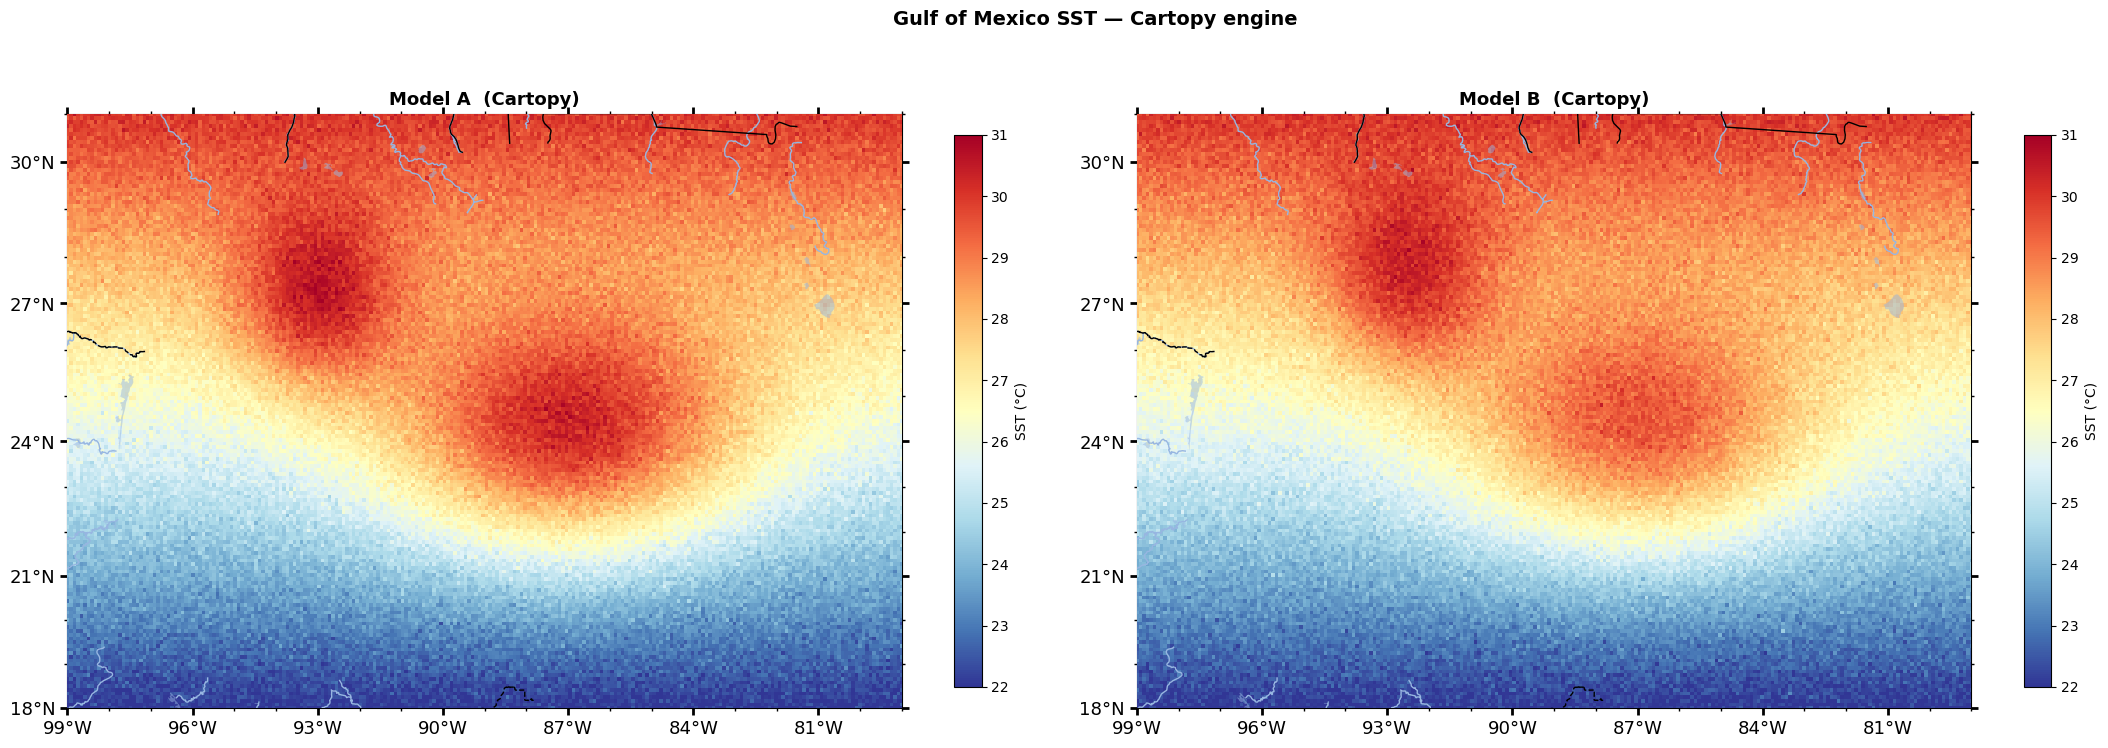

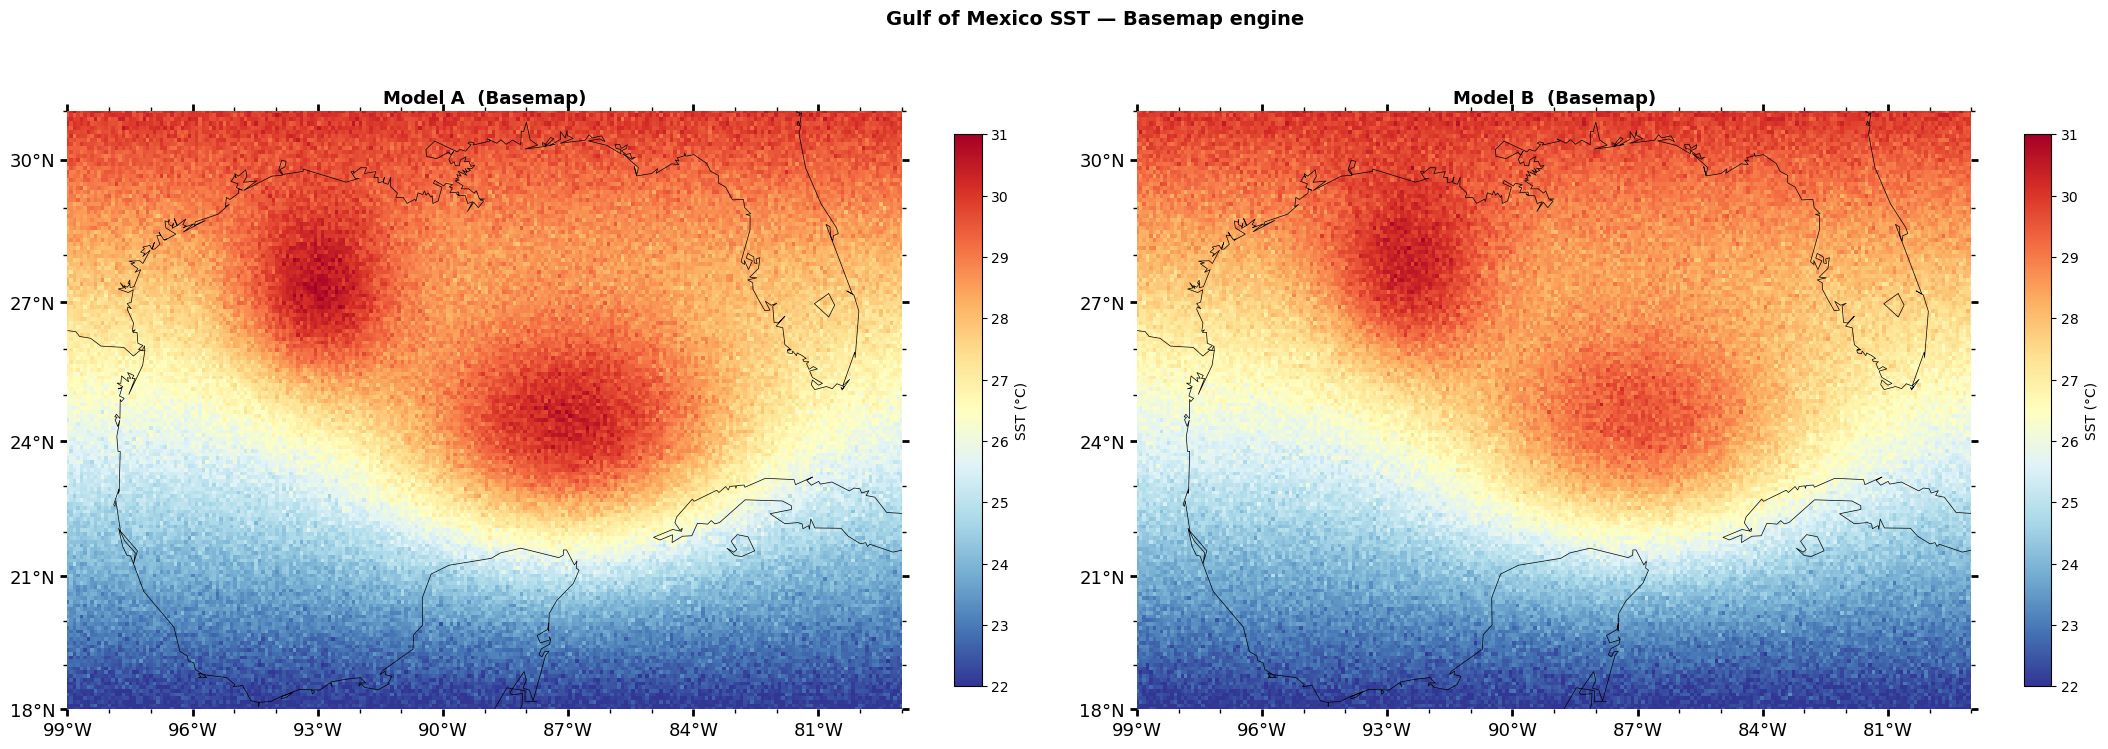

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ── Synthetic SST fields ────────────────────────────────────────────────────
# 1/12° resolution over the Gulf of Mexico (~HYCOM low-res output)
N_LON, N_LAT = 240, 156

lon_1d = np.linspace(EXTENT[0], EXTENT[1], N_LON)
lat_1d = np.linspace(EXTENT[2], EXTENT[3], N_LAT)
LONS, LATS = np.meshgrid(lon_1d, lat_1d)

# Background SST gradient: warm south (~30°C), cooler north (~22°C)
_gradient = (LATS - EXTENT[2]) / (EXTENT[3] - EXTENT[2]) * 8 + 22

# Loop Current warm core centred around (-87°, 24°)
_loop = np.exp(-((LONS + 87) ** 2 / 18 + (LATS - 24) ** 2 / 7)) * 4.5

# Warm-core ring shed from the Loop Current (~-93°, 27°)
_ring = np.exp(-((LONS + 93) ** 2 / 4 + (LATS - 27) ** 2 / 4)) * 2.8

rng = np.random.default_rng(42)
SST_A = _gradient + _loop + _ring + rng.standard_normal((N_LAT, N_LON)) * 0.25
# Model B: weaker Loop Current, ring shifted slightly — realistic model disagreement
_ring_b = np.exp(-((LONS + 92.5) ** 2 / 4 + (LATS - 27.4) ** 2 / 4)) * 2.4
SST_B = _gradient + _loop * 0.82 + _ring_b + rng.standard_normal((N_LAT, N_LON)) * 0.25

VMIN, VMAX = 22, 31
CMAP = "RdYlBu_r"

print(f"Grid: {N_LON} × {N_LAT}  ({N_LON * N_LAT:,} points per panel)")


# ── Cartopy dual-panel ──────────────────────────────────────────────────────
if "cartopy" in ENGINES:
    import cartopy.crs as ccrs

    proj = ccrs.Mercator()
    transform = ccrs.PlateCarree()

    fig = plt.figure(figsize=(22, 8))
    ax1 = fig.add_subplot(1, 2, 1, projection=proj)
    ax2 = fig.add_subplot(1, 2, 2, projection=proj)

    cplt.create(EXTENT, ax=ax1, engine="cartopy", coast="low", ticks=True)
    cplt.create(EXTENT, ax=ax2, engine="cartopy", coast="low", ticks=True)

    h1 = ax1.pcolormesh(LONS, LATS, SST_A, transform=transform,
                        cmap=CMAP, vmin=VMIN, vmax=VMAX, shading="auto", zorder=10)
    h2 = ax2.pcolormesh(LONS, LATS, SST_B, transform=transform,
                        cmap=CMAP, vmin=VMIN, vmax=VMAX, shading="auto", zorder=10)

    plt.colorbar(h1, ax=ax1, label="SST (°C)", shrink=0.75)
    plt.colorbar(h2, ax=ax2, label="SST (°C)", shrink=0.75)
    ax1.set_title("Model A  (Cartopy)", fontsize=13, fontweight="bold")
    ax2.set_title("Model B  (Cartopy)", fontsize=13, fontweight="bold")
    fig.suptitle("Gulf of Mexico SST — Cartopy engine", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


# ── Basemap dual-panel ──────────────────────────────────────────────────────
if "basemap" in ENGINES:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

    cplt.create(EXTENT, ax=ax1, engine="basemap", coast="low", ticks=True)
    cplt.create(EXTENT, ax=ax2, engine="basemap", coast="low", ticks=True)

    bm1 = getattr(ax1, "_cool_maps_basemap")
    bm2 = getattr(ax2, "_cool_maps_basemap")

    x1, y1 = bm1(LONS, LATS)   # project once
    x2, y2 = bm2(LONS, LATS)

    h1 = ax1.pcolormesh(x1, y1, SST_A, cmap=CMAP, vmin=VMIN, vmax=VMAX,
                        shading="auto", zorder=10)
    h2 = ax2.pcolormesh(x2, y2, SST_B, cmap=CMAP, vmin=VMIN, vmax=VMAX,
                        shading="auto", zorder=10)

    plt.colorbar(h1, ax=ax1, label="SST (°C)", shrink=0.75)
    plt.colorbar(h2, ax=ax2, label="SST (°C)", shrink=0.75)
    ax1.set_title("Model A  (Basemap)", fontsize=13, fontweight="bold")
    ax2.set_title("Model B  (Basemap)", fontsize=13, fontweight="bold")
    fig.suptitle("Gulf of Mexico SST — Basemap engine", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

Resolution             Engine       map init  data+cbar      total
----------------------------------------------------------
1/12°  (240×156)       cartopy          0.01s       0.03s      0.04s
1/12°  (240×156)       basemap          0.14s       0.02s      0.16s

1/25°  (500×325)       cartopy          0.01s       0.10s      0.11s
1/25°  (500×325)       basemap          0.15s       0.04s      0.19s

1/50°  (1000×650)      cartopy          0.01s       0.37s      0.38s
1/50°  (1000×650)      basemap          0.16s       0.18s      0.34s



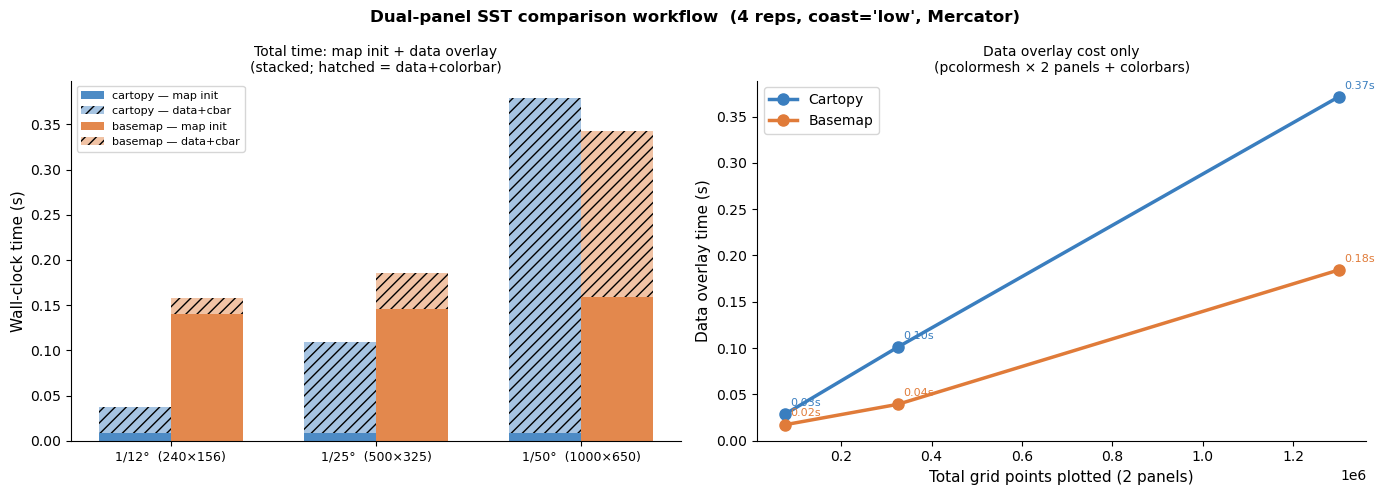


Speedup: Cartopy total / Basemap total
  1/12°  (240×156): 0.2× — Cartopy faster  (Cartopy 0.04s vs Basemap 0.16s)
  1/25°  (500×325): 0.6× — Cartopy faster  (Cartopy 0.11s vs Basemap 0.19s)
  1/50°  (1000×650): 1.1× — Basemap faster  (Cartopy 0.38s vs Basemap 0.34s)


In [8]:
import time
import matplotlib.pyplot as plt
import numpy as np

N_REPS = 4

# Resolutions matching real ocean model outputs
MODEL_RESOLUTIONS = {
    "1/12°  (240×156)": (240, 156),
    "1/25°  (500×325)": (500, 325),
    "1/50°  (1000×650)": (1000, 650),
}


def _make_sst_pair(n_lon, n_lat):
    lon_1d = np.linspace(EXTENT[0], EXTENT[1], n_lon)
    lat_1d = np.linspace(EXTENT[2], EXTENT[3], n_lat)
    lons, lats = np.meshgrid(lon_1d, lat_1d)
    grad = (lats - EXTENT[2]) / (EXTENT[3] - EXTENT[2]) * 8 + 22
    loop = np.exp(-((lons + 87) ** 2 / 18 + (lats - 24) ** 2 / 7)) * 4.5
    rng = np.random.default_rng(0)
    sst_a = grad + loop + rng.standard_normal((n_lat, n_lon)) * 0.25
    sst_b = grad + loop * 0.82 + rng.standard_normal((n_lat, n_lon)) * 0.25
    return lons, lats, sst_a, sst_b


def _time_cartopy(lons, lats, sst_a, sst_b, n):
    import cartopy.crs as ccrs
    proj = ccrs.Mercator()
    transform = ccrs.PlateCarree()
    init_times, data_times = [], []
    for _ in range(n):
        t0 = time.perf_counter()
        fig = plt.figure(figsize=(22, 8))
        ax1 = fig.add_subplot(1, 2, 1, projection=proj)
        ax2 = fig.add_subplot(1, 2, 2, projection=proj)
        cplt.create(EXTENT, ax=ax1, engine="cartopy", coast="low", ticks=False)
        cplt.create(EXTENT, ax=ax2, engine="cartopy", coast="low", ticks=False)
        t1 = time.perf_counter()
        ax1.pcolormesh(lons, lats, sst_a, transform=transform,
                       cmap="RdYlBu_r", vmin=22, vmax=31, shading="auto", zorder=10)
        ax2.pcolormesh(lons, lats, sst_b, transform=transform,
                       cmap="RdYlBu_r", vmin=22, vmax=31, shading="auto", zorder=10)
        plt.colorbar(ax1.collections[-1], ax=ax1, shrink=0.75)
        plt.colorbar(ax2.collections[-1], ax=ax2, shrink=0.75)
        t2 = time.perf_counter()
        init_times.append(t1 - t0)
        data_times.append(t2 - t1)
        plt.close(fig)
    return np.mean(init_times), np.mean(data_times)


def _time_basemap(lons, lats, sst_a, sst_b, n):
    init_times, data_times = [], []
    for _ in range(n):
        t0 = time.perf_counter()
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
        cplt.create(EXTENT, ax=ax1, engine="basemap", coast="low", ticks=False)
        cplt.create(EXTENT, ax=ax2, engine="basemap", coast="low", ticks=False)
        bm1 = getattr(ax1, "_cool_maps_basemap")
        bm2 = getattr(ax2, "_cool_maps_basemap")
        t1 = time.perf_counter()
        x1, y1 = bm1(lons, lats)   # project once per panel
        x2, y2 = bm2(lons, lats)
        ax1.pcolormesh(x1, y1, sst_a, cmap="RdYlBu_r", vmin=22, vmax=31,
                       shading="auto", zorder=10)
        ax2.pcolormesh(x2, y2, sst_b, cmap="RdYlBu_r", vmin=22, vmax=31,
                       shading="auto", zorder=10)
        plt.colorbar(ax1.collections[-1], ax=ax1, shrink=0.75)
        plt.colorbar(ax2.collections[-1], ax=ax2, shrink=0.75)
        t2 = time.perf_counter()
        init_times.append(t1 - t0)
        data_times.append(t2 - t1)
        plt.close(fig)
    return np.mean(init_times), np.mean(data_times)


# ── Run ─────────────────────────────────────────────────────────────────────
rows = []   # (res_label, engine, init_mean, data_mean)

print(f"{'Resolution':<22} {'Engine':<10} {'map init':>10} {'data+cbar':>10} {'total':>10}")
print("-" * 58)

for res_label, (n_lon, n_lat) in MODEL_RESOLUTIONS.items():
    lons, lats, sst_a, sst_b = _make_sst_pair(n_lon, n_lat)
    for engine, fn in [("cartopy", _time_cartopy), ("basemap", _time_basemap)]:
        if engine not in ENGINES:
            continue
        t_init, t_data = fn(lons, lats, sst_a, sst_b, N_REPS)
        rows.append((res_label, engine, t_init, t_data))
        print(f"{res_label:<22} {engine:<10} {t_init:>10.2f}s {t_data:>10.2f}s {t_init+t_data:>9.2f}s")
    print()

# ── Plot ─────────────────────────────────────────────────────────────────────
res_labels = list(MODEL_RESOLUTIONS.keys())
engine_colors = {"cartopy": "#3a7ebf", "basemap": "#e07b39"}
hatch = {"map init": "", "data+cbar": "///"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Left: stacked bar — init vs data cost breakdown
ax = axes[0]
x = np.arange(len(res_labels))
bar_w = 0.35
present_engines = [e for e in ("cartopy", "basemap") if e in ENGINES]

for i, engine in enumerate(present_engines):
    eng_rows = [r for r in rows if r[1] == engine]
    inits = [r[2] for r in eng_rows]
    datas = [r[3] for r in eng_rows]
    offset = (i - (len(present_engines) - 1) / 2) * bar_w
    color = engine_colors[engine]
    b1 = ax.bar(x + offset, inits, bar_w, label=f"{engine} — map init",
                color=color, alpha=0.9)
    b2 = ax.bar(x + offset, datas, bar_w, bottom=inits,
                label=f"{engine} — data+cbar",
                color=color, alpha=0.45, hatch="///")

ax.set_xticks(x)
ax.set_xticklabels(res_labels, fontsize=9)
ax.set_ylabel("Wall-clock time (s)", fontsize=11)
ax.set_title("Total time: map init + data overlay\n(stacked; hatched = data+colorbar)",
             fontsize=10)
ax.legend(fontsize=8, loc="upper left")
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)

# Right: data-only cost as a line chart to show scaling
ax2 = axes[1]
grid_totals = [n_lon * n_lat * 2 for n_lon, n_lat in MODEL_RESOLUTIONS.values()]

for engine in present_engines:
    eng_rows = [r for r in rows if r[1] == engine]
    data_costs = [r[3] for r in eng_rows]
    ax2.plot(grid_totals, data_costs,
             marker="o", linewidth=2.5, markersize=8,
             color=engine_colors[engine], label=engine.title())
    for gp, dc in zip(grid_totals, data_costs):
        ax2.annotate(f"{dc:.2f}s", (gp, dc),
                     textcoords="offset points", xytext=(4, 6),
                     fontsize=8, color=engine_colors[engine])

ax2.set_xlabel("Total grid points plotted (2 panels)", fontsize=11)
ax2.set_ylabel("Data overlay time (s)", fontsize=11)
ax2.set_title("Data overlay cost only\n(pcolormesh × 2 panels + colorbars)", fontsize=10)
ax2.legend(fontsize=10)
ax2.set_ylim(bottom=0)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Dual-panel SST comparison workflow  ({N_REPS} reps, coast='low', Mercator)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()
plt.close(fig)

# ── Crossover summary ────────────────────────────────────────────────────────
if len(present_engines) == 2:
    print("\nSpeedup: Cartopy total / Basemap total")
    for res_label in res_labels:
        c = next(r for r in rows if r[1] == "cartopy" and r[0] == res_label)
        b = next(r for r in rows if r[1] == "basemap" and r[0] == res_label)
        c_total = c[2] + c[3]
        b_total = b[2] + b[3]
        ratio = c_total / b_total
        winner = "Basemap" if ratio > 1 else "Cartopy"
        print(f"  {res_label}: {ratio:.1f}× — {winner} faster  "
              f"(Cartopy {c_total:.2f}s vs Basemap {b_total:.2f}s)")

---
## 13. Time-Step Loop: The Real Production Workflow

A single dual-panel map is rarely the end product. More commonly you loop over forecast hours or model snapshots to produce a sequence of frames that get assembled into an animation or a report.

Three strategies are compared:

| Strategy | Per-frame work |
|----------|---------------|
| **Cartopy — full rebuild** | `create()` + `pcolormesh(..., transform=)` every frame. |
| **Basemap — full rebuild** | `create()` + `bm(lons, lats)` + `pcolormesh` every frame. |
| **Basemap — pre-project** | `create()` once; `bm(lons, lats)` once; then per frame only `h.set_array()` updates the data in-place. No reprojection, no new artist. |

The pre-project strategy works because the map extent and projection never change between frames — only the scalar field values do. `set_array()` swaps the underlying colour data without touching the coordinate geometry.

Grid: 500×325  |  24 frames  |  2 panels

Running Cartopy full rebuild ...
Running Basemap full rebuild  ...
Running Basemap pre-project   ...

Strategy                       mean/frame  total (24 frames)
--------------------------------------------------------------
Cartopy full rebuild               0.096s              2.30s
Basemap full rebuild               0.171s              4.10s
Basemap pre-project                0.078s              1.87s


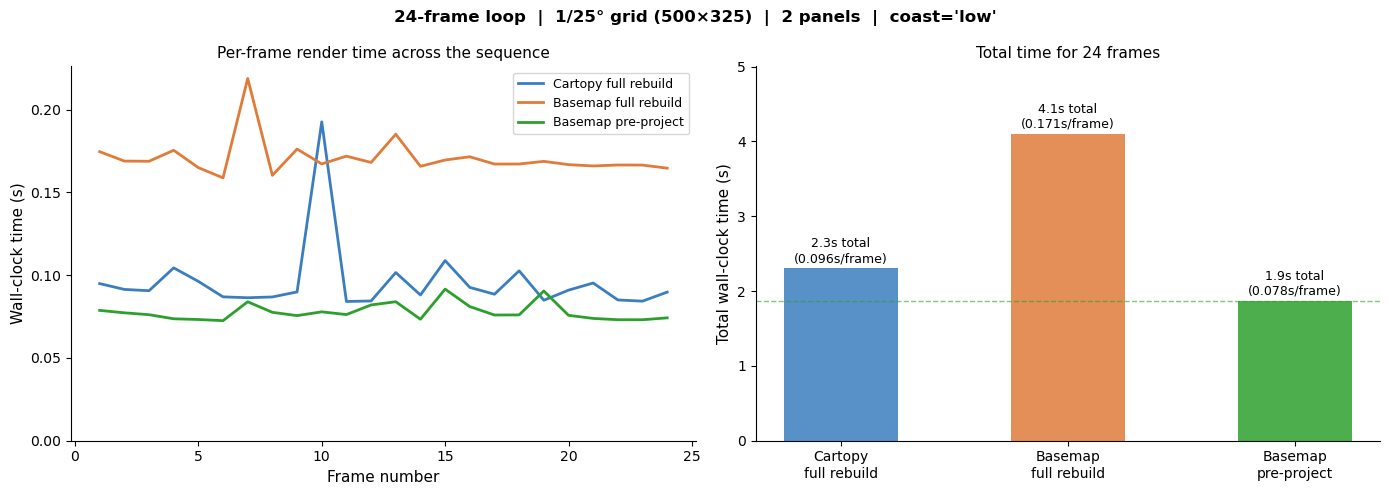


Basemap pre-project is 1.2× faster than Cartopy full rebuild over 24 frames.
Time saved: 0.4s  (0.0 minutes for a 240-frame animation).


In [9]:
import time
import matplotlib.pyplot as plt
import numpy as np

# ── Config ───────────────────────────────────────────────────────────────────
N_FRAMES = 24          # e.g. 24-hour forecast, one frame per hour
N_LON, N_LAT = 500, 325    # 1/25° — the crossover resolution from Section 12

lon_1d = np.linspace(EXTENT[0], EXTENT[1], N_LON)
lat_1d = np.linspace(EXTENT[2], EXTENT[3], N_LAT)
LONS_TS, LATS_TS = np.meshgrid(lon_1d, lat_1d)

rng = np.random.default_rng(7)

# Pre-build all frames: a slowly evolving SST field
base = (LATS_TS - EXTENT[2]) / (EXTENT[3] - EXTENT[2]) * 8 + 22
loop = np.exp(-((LONS_TS + 87) ** 2 / 18 + (LATS_TS - 24) ** 2 / 7)) * 4.5
FRAMES_A = [
    base + loop * (1 - 0.01 * t) + rng.standard_normal((N_LAT, N_LON)) * 0.2
    for t in range(N_FRAMES)
]
FRAMES_B = [
    base + loop * (0.82 - 0.008 * t) + rng.standard_normal((N_LAT, N_LON)) * 0.2
    for t in range(N_FRAMES)
]


# ── Strategy 1: Cartopy full rebuild every frame ──────────────────────────────
def loop_cartopy_rebuild(frames_a, frames_b):
    import cartopy.crs as ccrs
    proj = ccrs.Mercator()
    transform = ccrs.PlateCarree()
    frame_times = []
    for sst_a, sst_b in zip(frames_a, frames_b):
        t0 = time.perf_counter()
        fig = plt.figure(figsize=(22, 8))
        ax1 = fig.add_subplot(1, 2, 1, projection=proj)
        ax2 = fig.add_subplot(1, 2, 2, projection=proj)
        cplt.create(EXTENT, ax=ax1, engine="cartopy", coast="low", ticks=False)
        cplt.create(EXTENT, ax=ax2, engine="cartopy", coast="low", ticks=False)
        ax1.pcolormesh(LONS_TS, LATS_TS, sst_a, transform=transform,
                       cmap="RdYlBu_r", vmin=22, vmax=31, shading="auto", zorder=10)
        ax2.pcolormesh(LONS_TS, LATS_TS, sst_b, transform=transform,
                       cmap="RdYlBu_r", vmin=22, vmax=31, shading="auto", zorder=10)
        frame_times.append(time.perf_counter() - t0)
        plt.close(fig)
    return frame_times


# ── Strategy 2: Basemap full rebuild every frame ──────────────────────────────
def loop_basemap_rebuild(frames_a, frames_b):
    frame_times = []
    for sst_a, sst_b in zip(frames_a, frames_b):
        t0 = time.perf_counter()
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
        cplt.create(EXTENT, ax=ax1, engine="basemap", coast="low", ticks=False)
        cplt.create(EXTENT, ax=ax2, engine="basemap", coast="low", ticks=False)
        bm1 = getattr(ax1, "_cool_maps_basemap")
        bm2 = getattr(ax2, "_cool_maps_basemap")
        x1, y1 = bm1(LONS_TS, LATS_TS)
        x2, y2 = bm2(LONS_TS, LATS_TS)
        ax1.pcolormesh(x1, y1, sst_a, cmap="RdYlBu_r", vmin=22, vmax=31,
                       shading="auto", zorder=10)
        ax2.pcolormesh(x2, y2, sst_b, cmap="RdYlBu_r", vmin=22, vmax=31,
                       shading="auto", zorder=10)
        frame_times.append(time.perf_counter() - t0)
        plt.close(fig)
    return frame_times


# ── Strategy 3: Basemap pre-project — build once, update in-place each frame ──
def loop_basemap_preproject(frames_a, frames_b):
    frame_times = []

    # ---- setup (paid once, not included in per-frame timing) ----------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
    cplt.create(EXTENT, ax=ax1, engine="basemap", coast="low", ticks=False)
    cplt.create(EXTENT, ax=ax2, engine="basemap", coast="low", ticks=False)
    bm1 = getattr(ax1, "_cool_maps_basemap")
    bm2 = getattr(ax2, "_cool_maps_basemap")

    x1, y1 = bm1(LONS_TS, LATS_TS)   # project once — reused every frame
    x2, y2 = bm2(LONS_TS, LATS_TS)

    # Draw the first frame to create the artist handles
    h1 = ax1.pcolormesh(x1, y1, frames_a[0], cmap="RdYlBu_r",
                        vmin=22, vmax=31, shading="auto", zorder=10)
    h2 = ax2.pcolormesh(x2, y2, frames_b[0], cmap="RdYlBu_r",
                        vmin=22, vmax=31, shading="auto", zorder=10)
    # ---- end setup ----------------------------------------------------------

    for sst_a, sst_b in zip(frames_a, frames_b):
        t0 = time.perf_counter()
        # Only the scalar data changes — no geometry, no reprojection
        h1.set_array(sst_a.ravel())
        h2.set_array(sst_b.ravel())
        fig.canvas.draw()           # force a render (mimics savefig cost)
        frame_times.append(time.perf_counter() - t0)

    plt.close(fig)
    return frame_times


# ── Run ───────────────────────────────────────────────────────────────────────
print(f"Grid: {N_LON}×{N_LAT}  |  {N_FRAMES} frames  |  2 panels\n")

results_ts = {}

if "cartopy" in ENGINES:
    print("Running Cartopy full rebuild ...", flush=True)
    results_ts["Cartopy\nfull rebuild"] = loop_cartopy_rebuild(FRAMES_A, FRAMES_B)

if "basemap" in ENGINES:
    print("Running Basemap full rebuild  ...", flush=True)
    results_ts["Basemap\nfull rebuild"] = loop_basemap_rebuild(FRAMES_A, FRAMES_B)

    print("Running Basemap pre-project   ...", flush=True)
    results_ts["Basemap\npre-project"] = loop_basemap_preproject(FRAMES_A, FRAMES_B)

# ── Per-frame summary ─────────────────────────────────────────────────────────
print(f"\n{'Strategy':<28} {'mean/frame':>12} {'total (' + str(N_FRAMES) + ' frames)':>18}")
print("-" * 62)
for label, times in results_ts.items():
    flat_label = label.replace("\n", " ")
    mean_t = np.mean(times)
    total_t = np.sum(times)
    print(f"{flat_label:<28} {mean_t:>11.3f}s {total_t:>17.2f}s")

# ── Plot ─────────────────────────────────────────────────────────────────────
strategy_colors = {
    "Cartopy\nfull rebuild":  "#3a7ebf",
    "Basemap\nfull rebuild":  "#e07b39",
    "Basemap\npre-project":   "#2ca02c",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-frame time over the sequence (shows warm-up / caching effects)
ax = axes[0]
for label, times in results_ts.items():
    ax.plot(range(1, len(times) + 1), times,
            color=strategy_colors[label], linewidth=2,
            label=label.replace("\n", " "))
ax.set_xlabel("Frame number", fontsize=11)
ax.set_ylabel("Wall-clock time (s)", fontsize=11)
ax.set_title("Per-frame render time across the sequence", fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)

# Right: total time bar chart
ax2 = axes[1]
labels = list(results_ts.keys())
totals = [np.sum(t) for t in results_ts.values()]
means  = [np.mean(t) for t in results_ts.values()]
colors = [strategy_colors[l] for l in labels]

bars = ax2.bar(range(len(labels)), totals, color=colors, alpha=0.85, width=0.5)
for bar, total, mean in zip(bars, totals, means):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(totals) * 0.01,
             f"{total:.1f}s total\n({mean:.3f}s/frame)",
             ha="center", va="bottom", fontsize=9)

ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels([l.replace("\n", "\n") for l in labels], fontsize=10)
ax2.set_ylabel("Total wall-clock time (s)", fontsize=11)
ax2.set_title(f"Total time for {N_FRAMES} frames", fontsize=11)
ax2.set_ylim(bottom=0, top=max(totals) * 1.22)
ax2.spines[["top", "right"]].set_visible(False)

if "Cartopy\nfull rebuild" in results_ts and "Basemap\npre-project" in results_ts:
    best = np.sum(results_ts["Basemap\npre-project"])
    worst = np.sum(results_ts["Cartopy\nfull rebuild"])
    ax2.axhline(best, color="#2ca02c", linewidth=1, linestyle="--", alpha=0.6)

fig.suptitle(
    f"{N_FRAMES}-frame loop  |  1/25° grid ({N_LON}×{N_LAT})  |  2 panels  |  coast='low'",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()
plt.close(fig)

# ── Speedup summary ───────────────────────────────────────────────────────────
if "Cartopy\nfull rebuild" in results_ts and "Basemap\npre-project" in results_ts:
    c_total = np.sum(results_ts["Cartopy\nfull rebuild"])
    b_total = np.sum(results_ts["Basemap\npre-project"])
    print(f"\nBasemap pre-project is {c_total / b_total:.1f}× faster than Cartopy full rebuild "
          f"over {N_FRAMES} frames.")
    print(f"Time saved: {c_total - b_total:.1f}s  "
          f"({(c_total - b_total) / 60:.1f} minutes for a 240-frame animation).")